# 1 Anwendung von Autoencoder zur Anomalieerkennung in Verkaufsdaten
### 1. **Aufgabenstellung**

Im Rahmen dieser Arbeit soll ein neuronales Netz in Form eines Autoencoders entwickelt werden, um Anomalien in Verkaufsdaten (Sales Data) zu erkennen. Ziel ist es, ein Modell zu trainieren, das typische Muster und Zusammenhänge in regulären Transaktionen erlernt und Abweichungen vom erwarteten Verhalten identifiziert.

 - Trainingsphase:
In der Trainingsphase wird der Autoencoder ausschließlich mit normalen Verkaufsdaten trainiert. Dabei soll das Modell charakteristische Strukturen, Wertebereiche und Zusammenhänge zwischen Merkmalen wie Rechnungsbetrag, Steuerwert, Zahlungsbedingungen, Land erlernen.

 -  Vorhersage- bzw. Testphase:
Anschließend wird das trainierte Modell auf neue, unbekannte Daten angewendet. Für jeden Datensatz wird der Rekonstruktionsfehler berechnet, der angibt, wie stark sich die rekonstruierten Werte von den tatsächlichen Werten unterscheiden.

 - Anomalieerkennung:
Datensätze mit einem signifikant hohen Rekonstruktionsfehler werden als potenzielle Anomalien markiert. Diese Anomalien können auf fehlerhafte, ungewöhnliche oder betrügerische Transaktionen hinweisen – etwa durch überhöhte Beträge, unplausible Steuerwerte oder atypische Kombinationen von Verkaufsmerkmalen.

### 2. **Zielsetzung**

Das Ziel dieser Arbeit ist es, den Einsatz eines Autoencoders zur automatisierten Anomalieerkennung zu untersuchen. Dabei soll gezeigt werden,

 - wie effektiv der Autoencoder normale Muster in den Daten erlernen kann,

 - in welchem Maße der Rekonstruktionsfehler zur Identifikation ungewöhnlicher Datensätze geeignet ist,

 - und welche Schwellenwerte (Thresholds) sich zur Unterscheidung zwischen normalen und anomalen Datenpunkten eignen.


### 3. **Methodik**
 1. Datenaufbereitung:

  - Bereinigung und Normalisierung der Verkaufsdaten

  - Trennung in Trainings- und Testdatensatz

  - Optionale Reduktion auf relevante Merkmale

 2.  Modellaufbau:

 - Implementierung eines symmetrischen Autoencoders mit geeigneter Architektur (hier Dense Layers )

 - Verwendung von Aktivierungsfunktionen wie ReLU

 - Optimierung mit Adam 

 3. Training und Evaluation:

  - Training ausschließlich auf normalen Datensätzen

  - Berechnung des Rekonstruktionsfehlers für alle Testdaten

  - Bestimmung eines Schwellenwerts zur Klassifikation von Anomalien

  - Visualisierung der Ergebnisse (z. B. Fehlerverteilung)

### 4. Die Architektur von Autoencoder**: Symmetrischer Aufbau: Encoder und Decoder
Der Hauptzweck ist das effiziente Erlernen und die Rekonstruktion einer komprimierten und informativen Darstellung von Daten.

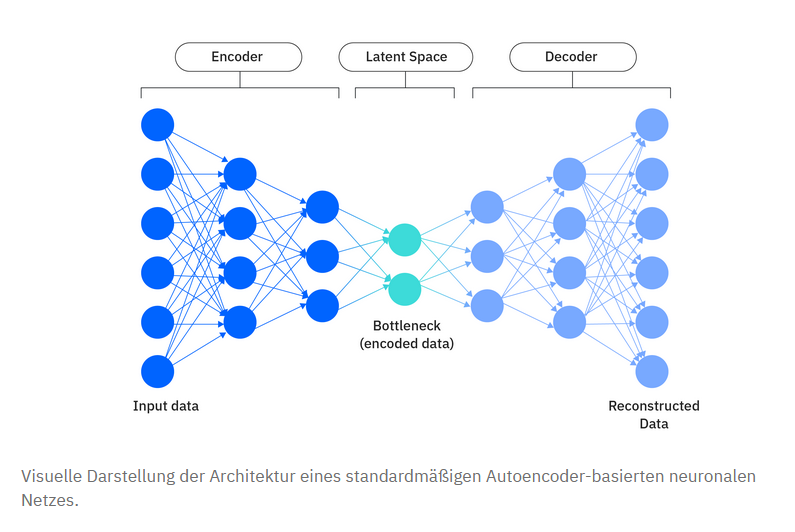

Abbildung stammt aus: https://www.ibm.com/de-de/think/topics/variational-autoencoder

#### Zweck des Encoders
Der Encoder nimmt die Eingabedaten  und reduziert sie auf einen niedrigdimensionalen Vektor, die latente Repräsentation. Das Ziel ist, die wichtigsten Merkmale des Originals zu komprimieren und dabei unwichtige Details und Rauschen zu verwerfen.

#### Zweck des Decoders
Der Decoder nimmt diese komprimierte Darstellung und versucht, daraus die ursprünglichen Daten möglichst genau zu rekonstruieren. Das Netzwerk lernt dabei, welche Merkmale für die Rekonstruktion unverzichtbar sind und wie unwichtige Informationen ignoriert werden

#### Einflussfaktor
- Die Streuung der Normaldaten: Standardabweichung (Schwankungsbereich)
- Flaschenhals: wie eng ist der Flaschenhals(bottleneck) ausgewählt ist: je enger, desto strenger und auch mehr Informationsverlust


# 2  Datenvorbereitung: Simulationsdaten

 ### Schritte zur Bereitstellung von Simulationsdaten

1. **Definition der Stammdaten (Normdaten)**:

Zunächst werden Stammdaten erstellt, die typische Verkaufsdaten innerhalb eines festgelegten Kalkulationszeitraums (z. B. 1 Woche) repräsentieren. Diese Stammdaten bilden die Grundlage der Simulation und enthalten charakteristische Werte für Merkmale wie Betrag, Steuer, Zahlungsbedingungen und weitere relevante Verkaufsparameter.
Die in den Stammdaten enthaltenen Werte entsprechen dabei den Erwartungswerten einer Normalverteilung und stellen somit das durchschnittliche, erwartete Verhalten normaler Verkaufsprozesse dar.

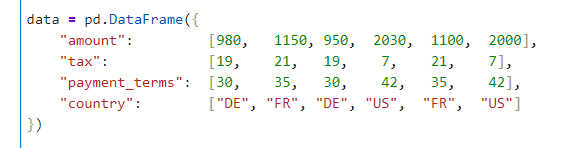

2. **Erzeugung der Simulationsdaten:**

   
Auf Basis der Stammdaten werden erweiterte Simulationsdaten für einen längeren Zeitraum (z. B. 500 Einträge) generiert. Hierbei werden zufällige Schwankungen um die jeweiligen Mittelwerte eingefügt, um natürliche Varianzen und realistische Streuungen in den Daten zu simulieren.
Dadurch entsteht ein Datensatz, der sowohl die typischen Muster als auch zufällige Abweichungen des Verkaufsprozesses abbildet.

3. **Charakteristik der Daten:**

   
Obwohl die simulierten Datensätze zeitlich erzeugt werden, handelt es sich dabei nicht um eine Zeitreihe, da die zeitliche Reihenfolge der Datenpunkte für die Analyse keine Bedeutung hat. Jeder Datensatz kann unabhängig von der zeitlichen Abfolge betrachtet werden.

4. **Datenqualität:**
 
Da die Simulationsdaten kontrolliert erzeugt werden, ist keine gesonderte Datenbereinigung erforderlich. Alle Datenpunkte sind vollständig und konsistent und können direkt für das Training des Autoencoders verwendet werden.

5. **Aufbau von Encoder-Decoder**
Input (6)

 ↓
Dense(16, relu)

 ↓
Dense(8, relu)

 ↓
Dense(3, relu)   ←  Bottleneck-Schicht:3, 4

 ↓
Dense(8, relu)

 ↓
Dense(16, relu)

 ↓
Dense(6, linear/sigmoid) → Rekonstruktion

Das ist ein symmetrischer Autoencoder,
bei dem der Encoder-Teil und der Decoder-Teil spiegelbildlich aufgebaut sind.

Warum ist das wichtig?

Der Bottleneck zwingt das Netzwerk, redundante oder unwichtige Informationen zu verwerfen, wesentliche Merkmale zu verdichten, und dadurch repräsentative Features zu lernen.

Das ist das, was man in der Praxis „Feature Learning“ nennt.

   amount  tax  payment_terms country
0     980   19             30      DE
1    1150   21             35      FR
2     950   19             30      DE
3    2030    7             42      US
4    1100   21             35      FR
5    2000    7             42      US
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          600 non-null    int64  
 1   amount         600 non-null    float64
 2   tax            600 non-null    int64  
 3   payment_terms  600 non-null    int64  
 4   country        600 non-null    object 
dtypes: float64(1), int64(3), object(1)
memory usage: 23.6+ KB

data_augmented.describe: amount
         count         mean        std          min          25%          50%  \
country                                                                         
DE       190.0   962.375500  33.935785   870.022812   938.494167

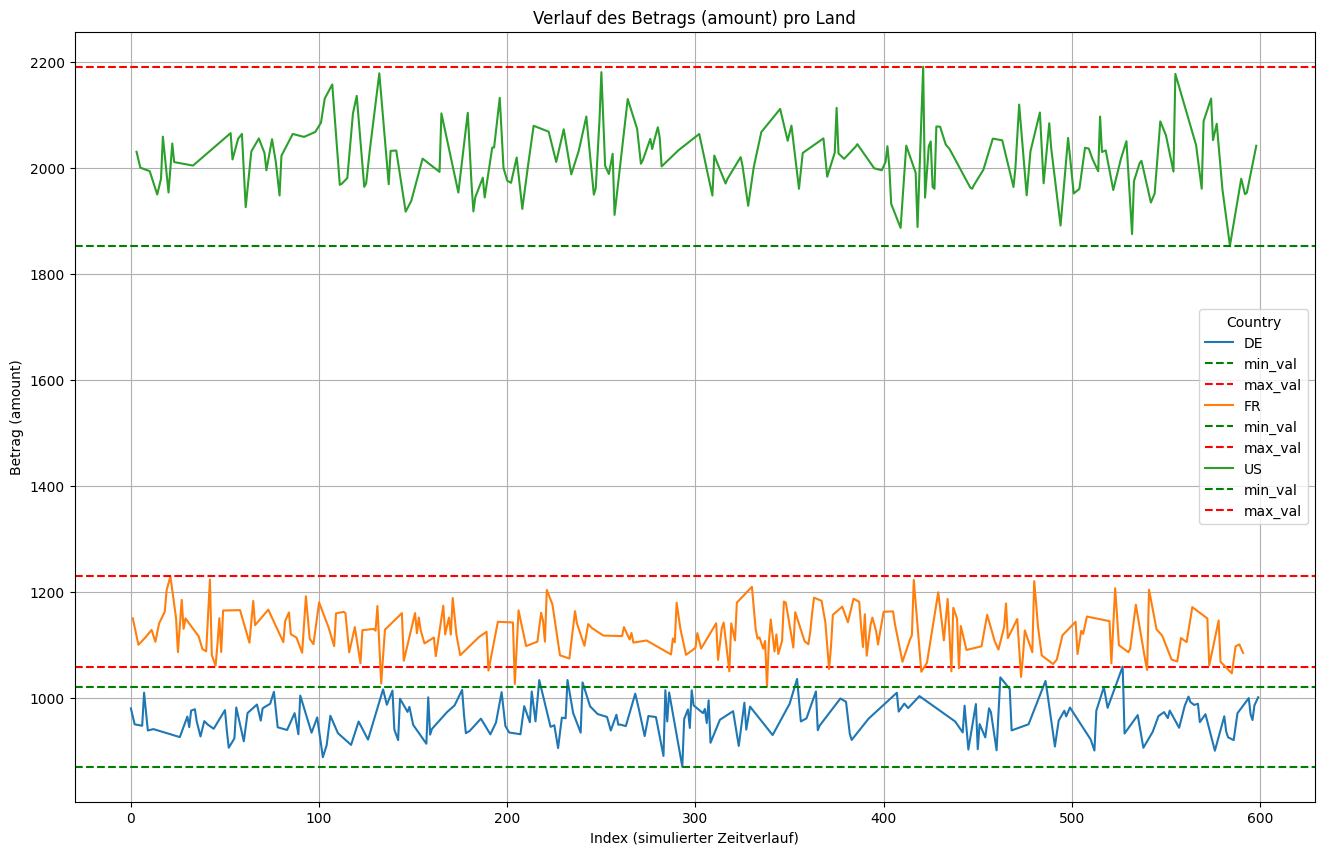

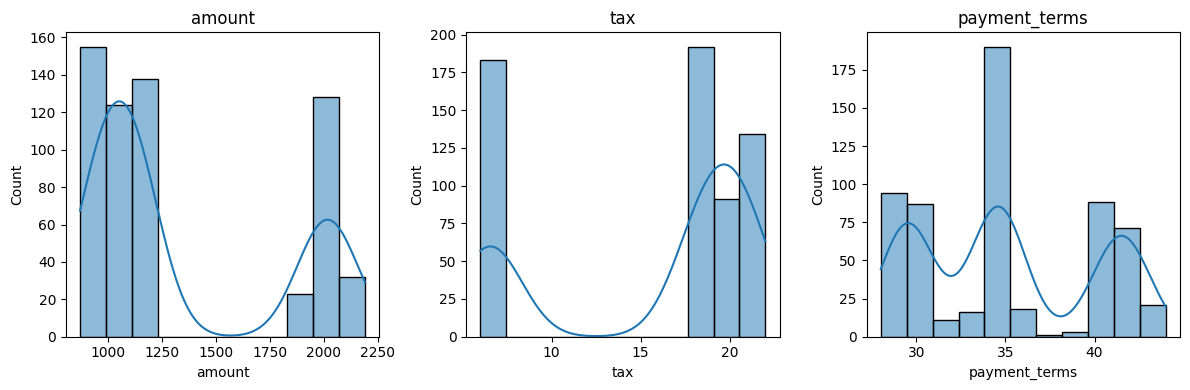

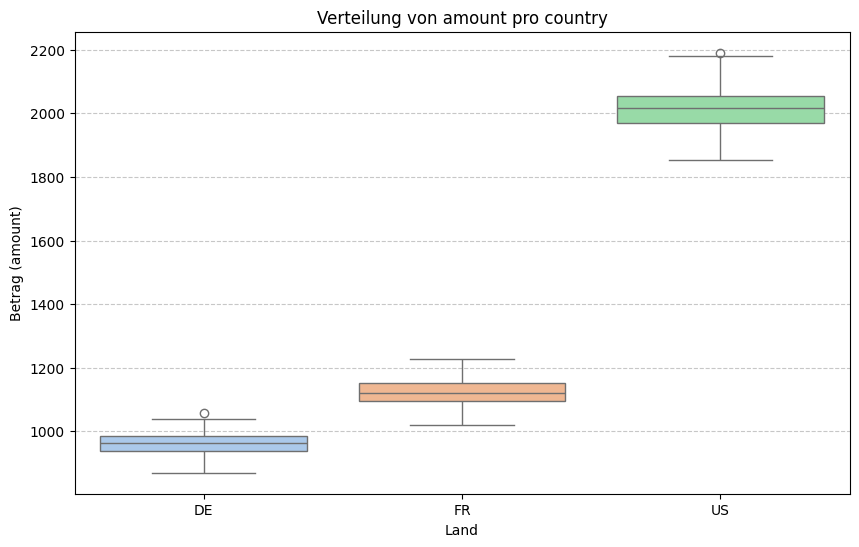

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
import random
import os

# 1️ Allgemeine Seeds setzen
seed_value = 42
os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

# 2️ TensorFlow deterministisch machen (optional, aber besser)
# verhindert, dass Operationen mit nicht-deterministischem Verhalten laufen
os.environ["TF_DETERMINISTIC_OPS"] = "1"

# Schritte für die Bereitstellung von Simulationsdaten 
# Definition von Stammdaten als Normale Daten für  Verkäufe in einem Kakulationszeitraum z.B.30 Tage
# die Werte in Stammdaten sind so eine Art von Erwartung(Mittelwert) einer normaler Verteilung 
# Erzeugung von Simulationsdaten für längere Zeitzyklen z.B. 500 durch Zufügen von zufälligen Schwankung in den Stammdaten.
# Die Daten entstehen zwar zeitlich, aber nicht als Zeitreihe zu betrachten weil die Reihenfolge keine Rolle spielen.
# Eine Datenbereinigung ist soweit nicht nötig.

# Stammdaten:

data = pd.DataFrame({
    "amount":         [980,   1150, 950,  2030,  1100,  2000],
    "tax":            [19,    21,   19,    7,    21,    7],
    "payment_terms":  [30,    35,   30,    42,   35,    42],
    "country":        ["DE", "FR", "DE", "US",  "FR",  "US"]
})

"""
data = pd.DataFrame({
    "amount": [950, 1100, 2000],
    "tax": [19, 21,  7],
    "payment_terms": [30, 35, 42],
    "country": ["DE", "FR", "US"]
})
"""

print(data)
target_rows = 600             # 600 : Anzahl gewünschter Zeilen für gesamten Daten
current_rows = len(data)
rows_to_add = target_rows - current_rows

# Zufällige Auswahl der vorhandenen Zeilen + kleine Variationen
np.random.seed(42)
new_rows = []
for _ in range(rows_to_add):
    row = data.sample(1).iloc[0].copy()                                          # nimmt zufällig genau eine Zeile aus dem DataFrame data
    row["amount"] = row["amount"] + np.random.normal(0, 0.03*row["amount"])      # 1% bis 3%
    row["tax"] = int(row["tax"]+ np.random.normal(0, 0.02*row["tax"]))           # 2%  Schwankung
    row["payment_terms"] = int(row["payment_terms"] +  np.random.normal(0, 0.02*row["payment_terms"])) #2% Schwankung
    new_rows.append(row) 

# Neue Zeilen zum DataFrame hinzufügen
data_augmented = pd.concat([data, pd.DataFrame(new_rows)], ignore_index=True)

data_augmented.reset_index(inplace=True)  # Index als "Zeitachse" benutzen
X= data_augmented
data_augmented.info()
#data_augmented.groupby("country")["amount"].max()

print("\ndata_augmented.describe: amount")
print( data_augmented.groupby("country")["amount"].describe())

# ======= Plot line =======
plt.figure(figsize=(16, 10))
for country, subset in data_augmented.groupby("country"):
    plt.plot(subset["index"], subset["amount"], label=country)
    min_val = subset["amount"].min()
    max_val = subset["amount"].max()
    plt.axhline(min_val, color="green", linestyle="--", label="min_val")
    plt.axhline(max_val, color="red", linestyle="--", label="max_val")

plt.title("Verlauf des Betrags (amount) pro Land")
plt.xlabel("Index (simulierter Zeitverlauf)")
plt.ylabel("Betrag (amount)")
plt.legend(title="Country")
plt.grid(True)
plt.show()


# plot histogram
fig, axs = plt.subplots(1, 3, figsize=(12,4))
sns.histplot(data_augmented["amount"], kde=True, ax=axs[0])
sns.histplot(data_augmented["tax"], kde=True, ax=axs[1])
sns.histplot(data_augmented["payment_terms"], kde=True, ax=axs[2])
axs[0].set_title("amount")
axs[1].set_title("tax")
axs[2].set_title("payment_terms")
plt.tight_layout()
plt.show()

# plot boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=data_augmented,
    x="country",
    y="amount",
    hue="country",       # neu!
    palette="pastel",
    legend=False         # verhindert doppelte Legende
)
plt.title("Verteilung von amount pro country")
plt.xlabel("Land")
plt.ylabel("Betrag (amount)")
plt.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.show()



# 3 train_test_split() + ColumnTransformer

In [2]:
from sklearn.model_selection import train_test_split

# 1. Train / Temp-Split
X_train_df, X_temp_df = train_test_split(X, test_size=0.3, random_state=42)

# 2. Temp-Split (Validation/Test, jeweils 50%)
X_val_df, X_test_df = train_test_split(X_temp_df, test_size=0.5, random_state=42)


print("X_train_df: data type:", type(X_train_df))
print("Train:", X_train_df.shape)
print("Val:  ", X_val_df.shape)
print("Test: ", X_test_df.shape)

# Preprocessing mit handle_unknown="ignore"
num_features = ["amount", "tax", "payment_terms"]
cat_features = ["country"]

# MinMaxScaler : sigmoid
# RobustScaler, StandardScaler: linear
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
])

# preprocessor: transfomer pandas Frame in numpy array
X_train = preprocessor.fit_transform(X_train_df)
X_val = preprocessor.transform(X_val_df)
X_test = preprocessor.transform(X_test_df)

print(f"X_train: {X_train.shape} (DE & FR & US)")
print(X_train)
#print(f"X_val: {X_val.shape[0]} (DE & FR & US)")
#print(f"X_test: {X_test.shape[0]} (DE & FR & US)")



X_train_df: data type: <class 'pandas.core.frame.DataFrame'>
Train: (420, 5)
Val:   (90, 5)
Test:  (90, 5)
X_train: (420, 6) (DE & FR & US)
[[-0.54421464  0.88245819 -0.21695472  0.          1.          0.        ]
 [ 1.48217103 -1.58403986  1.23269726  0.          0.          1.        ]
 [-0.75741877  0.55359179 -1.04532728  1.          0.          0.        ]
 ...
 [-0.80954473  0.38915858 -1.25242042  1.          0.          0.        ]
 [ 1.52984633 -1.58403986  1.4397904   0.          0.          1.        ]
 [-1.00736176  0.38915858 -1.25242042  1.          0.          0.        ]]


# 4 Autoencoder-Modell: Encoder +Decoder

## Flaschenhals-Dimension: 

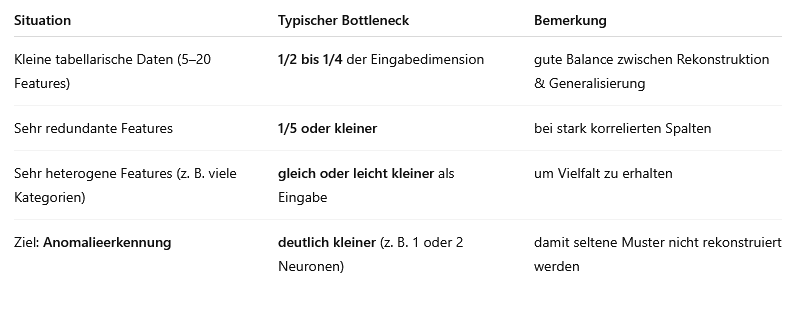

## Aufbau von Encoder und Decoder:

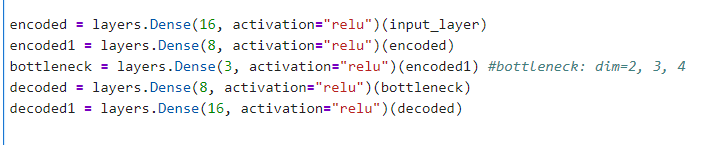



## 4.1 Training

input_dim: 6
Epoch 1/60
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5938 - r2_score: -0.0924 - val_loss: 0.5127 - val_r2_score: 0.0076
Epoch 2/60
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3270 - r2_score: 0.3122 - val_loss: 0.1777 - val_r2_score: 0.5910
Epoch 3/60
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1403 - r2_score: 0.6559 - val_loss: 0.1167 - val_r2_score: 0.6873
Epoch 4/60
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1124 - r2_score: 0.6969 - val_loss: 0.1056 - val_r2_score: 0.7084
Epoch 5/60
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1037 - r2_score: 0.7197 - val_loss: 0.0998 - val_r2_score: 0.7332
Epoch 6/60
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0944 - r2_score: 0.7606 - val_loss: 0.0867 - val_r2_score: 0.7919
Epoch 7/60
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0762 - r2_score: 0.8274 - val_loss: 0.0662 - val_r2_score: 0.8559
Epoch 8/60
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0561 - r2_score: 0.8844 - va

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │            54 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 653 (2.55 KB)

 Trainable params: 217 (868.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 436 (1.71 KB)

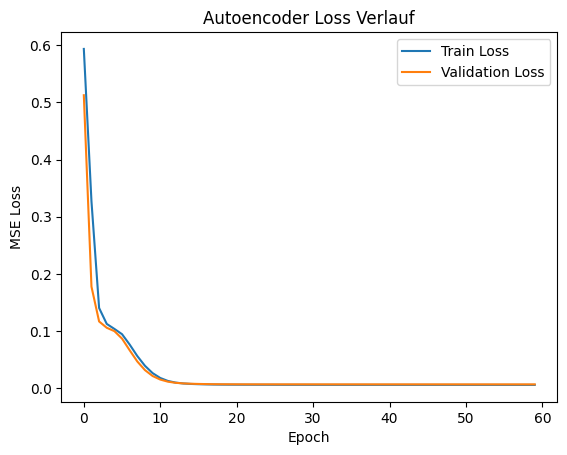

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models

input_dim = X_train.shape[1]
print("input_dim:", input_dim) #=6

input_layer = layers.Input(shape=(input_dim,))

"""
encoded = layers.Dense(8, activation="relu")(input_layer)
encoded1 = layers.Dense(4, activation="relu")(encoded)
bottleneck = layers.Dense(3, activation="relu")(encoded1) #bottleneck: dim=2, 3, 4
decoded = layers.Dense(4, activation="relu")(bottleneck)
decoded1 = layers.Dense(8, activation="relu")(decoded)

encoded = layers.Dense(16, activation="relu")(input_layer)
encoded1 = layers.Dense(8, activation="relu")(encoded)
bottleneck = layers.Dense(3, activation="relu")(encoded1) #bottleneck: dim=2, 3, 4
decoded = layers.Dense(8, activation="relu")(bottleneck)
decoded1 = layers.Dense(16, activation="relu")(decoded)

"""

encoded = layers.Dense(8, activation="relu")(input_layer)
encoded1 = layers.Dense(4, activation="relu")(encoded)
bottleneck = layers.Dense(3, activation="relu")(encoded1) #bottleneck: dim=2, 3, 4
decoded = layers.Dense(4, activation="relu")(bottleneck)
decoded1 = layers.Dense(8, activation="relu")(decoded)

# input_dim=6
# MinMaxScaler : sigmoid
# RobustScaler, StandardScaler: linear
#output_layer = layers.Dense(input_dim, activation="sigmoid")(decoded1)
output_layer = layers.Dense(input_dim, activation="linear")(decoded1)

autoencoder = models.Model(input_layer, output_layer)
autoencoder.compile(optimizer="adam", loss="mse", metrics=["r2_score"])

history = autoencoder.fit(
    X_train, X_train,
    epochs=60,
    batch_size=4,
    validation_data=(X_val, X_val),
    #shuffle=False, 
    verbose=1
)

autoencoder.summary()


plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Autoencoder Loss Verlauf")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()


# 4 Reconstructions für X_train und X_test
- Schwellenwert soll aus X_train berechnet werden. threshold_iqr = np.percentile(train_mse, 75) + 1.5 * iqr
- Kombination von verschiedenen Schwellenwerten

q95 = np.percentile(train_mse, 95)

q99 = np.percentile(train_mse, 99)

threshold_iqr = q75 + 1.5 * iqr  # iqr = q75 - q25 , q25, q75

threshold_90_iqr = np.percentile(train_mse, 90) + 0.5 * iqr

threshold_std = mean + 3 * std  
  
 

## 4.1 predict(X_train), predict(X_test)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
X_train: reconstructions.shape (420, 6)
thresholds_country: country
DE    0.017815
FR    0.030377
US    0.040854
Name: mse, dtype: float64
 len of mse, X_test: 90
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
 len of X_test: 90 90
X_test: reconstructions.shape (90, 6)
mse-test [0.01067368 0.00385795 0.00807631 0.00392165 0.00441958 0.01661482
 0.00444368 0.00321396 0.01098861 0.00711361 0.00434542 0.00229707
 0.0022087  0.00379869 0.00526917 0.00230005 0.0016438  0.01538403
 0.01616469 0.00281835 0.00177803 0.0155436  0.01563031 0.00293019
 0.00411695 0.0022342  0.00548495 0.00160894 0.01438277 0.00205986
 0.00164798 0.00161395 0.00421342 0.00215824 0.00321197 0.00247565
 0.00275185 0.00326896 0.00412502 0.00927859 0.0160656  0.00215802
 0.0123001  0.00404729 0.00423589 0.00292865 0.00323627 0.00406342
 0.00329421 0.01328083 0.0032165  0.00712713 0.013862   0.00228851
 0.00793584 0.00229421 0.00476855 0.00781884 0.00536847 0.00385195
 0.00366299 0.0008379

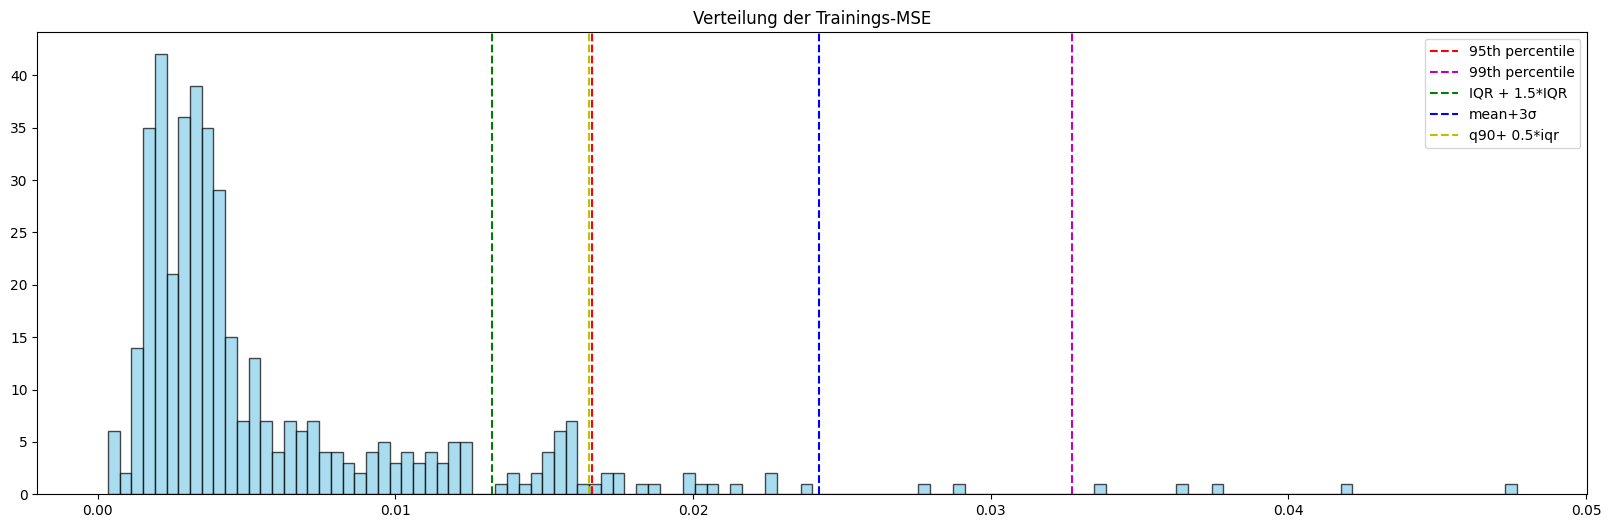

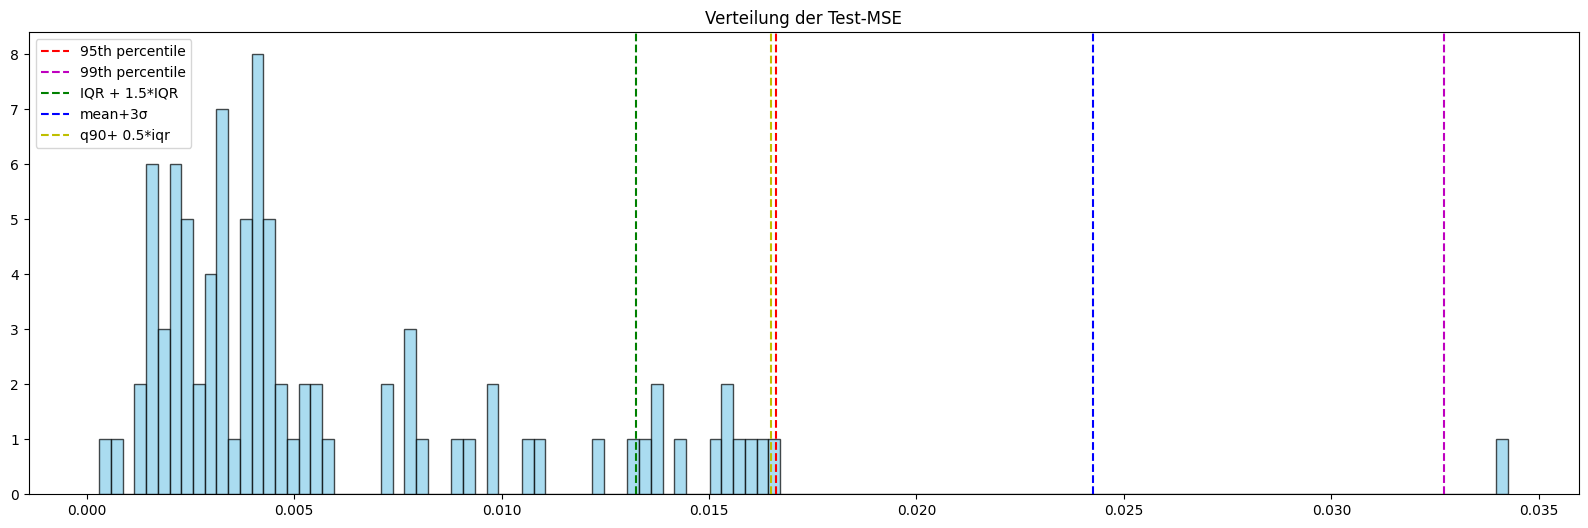

C:\0_DA\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\0_DA\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128997 (\N{LARGE RED SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


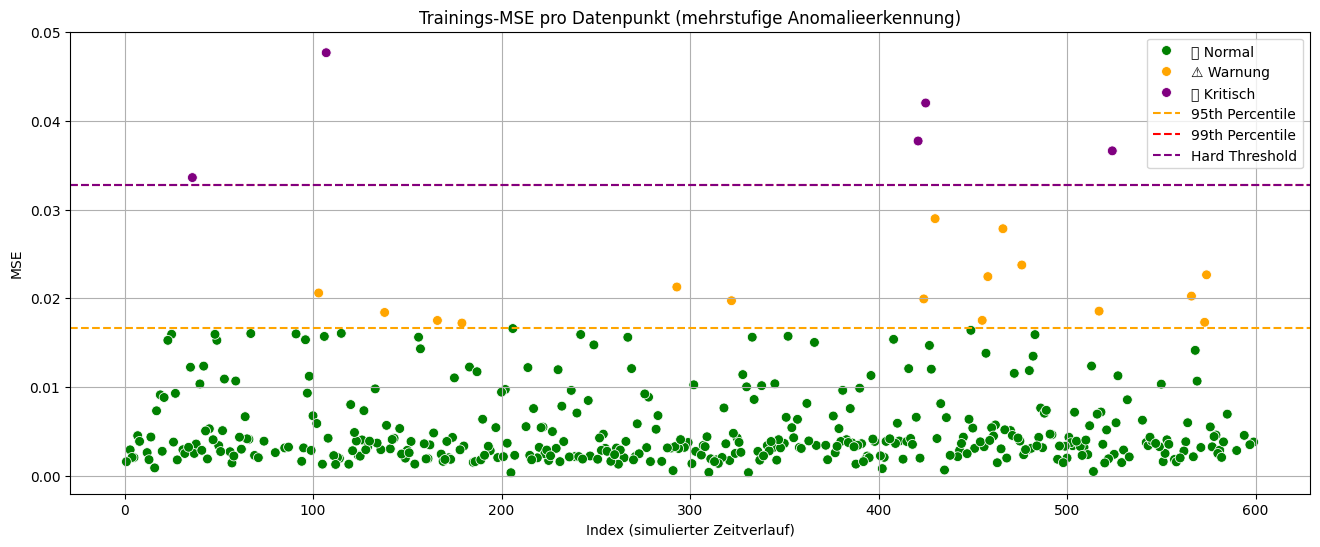

max. Threshold:  0.0327246010688125
======= Check X_train ======= 
152.  FR - MSE=0.03360 -> 🚨 Anomalie
186.  US - MSE=0.04201 -> 🚨 Anomalie
225.  US - MSE=0.03773 -> 🚨 Anomalie
257.  US - MSE=0.04768 -> 🚨 Anomalie
326.  FR - MSE=0.03662 -> 🚨 Anomalie
======= Check X_test ======= 
 1.  US - MSE=0.01067 -> ✅ Normal
 2.  FR - MSE=0.00386 -> ✅ Normal
 3.  FR - MSE=0.00808 -> ✅ Normal
 4.  FR - MSE=0.00392 -> ✅ Normal
 5.  DE - MSE=0.00442 -> ✅ Normal
 6.  US - MSE=0.01661 -> ✅ Normal
 7.  US - MSE=0.00444 -> ✅ Normal
 8.  FR - MSE=0.00321 -> ✅ Normal
 9.  US - MSE=0.01099 -> ✅ Normal
10.  US - MSE=0.00711 -> ✅ Normal
11.  FR - MSE=0.00435 -> ✅ Normal
12.  DE - MSE=0.00230 -> ✅ Normal
13.  US - MSE=0.00221 -> ✅ Normal
14.  DE - MSE=0.00380 -> ✅ Normal
15.  US - MSE=0.00527 -> ✅ Normal
16.  DE - MSE=0.00230 -> ✅ Normal
17.  DE - MSE=0.00164 -> ✅ Normal
18.  FR - MSE=0.01538 -> ✅ Normal
19.  FR - MSE=0.01616 -> ✅ Normal
20.  DE - MSE=0.00282 -> ✅ Normal
21.  FR - MSE=0.00178 -> ✅ Normal
22. 

,count,mean,std,min,25%,50%,75%,max
country,,,,,,,,
DE,135.0,0.004587,0.003908,0.001589,0.002491,0.003227,0.004620,0.021271
FR,157.0,0.005777,0.005739,0.001302,0.002235,0.003856,0.006551,0.036617
US,128.0,0.007508,0.007897,0.000338,0.002460,0.004376,0.010266,0.047677


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import normaltest
from sklearn.mixture import GaussianMixture


# Rekonstruktion von X_train:
train_recons = autoencoder.predict(X_train)
train_mse = np.mean(np.power(X_train - train_recons, 2), axis=1)
print("X_train: reconstructions.shape", train_recons.shape)

X_train_df["mse"] = train_mse
thresholds_country = X_train_df.groupby("country")["mse"].quantile(0.99)
print("thresholds_country:", thresholds_country)


# Rekonstruktion von X_test:
print(" len of mse, X_test:", len(X_test) )
reconstructions = autoencoder.predict(X_test)
test_mse = np.mean(np.power(X_test - reconstructions, 2), axis=1)
print(" len of X_test:", len( test_mse), len(X_test) )
print("X_test: reconstructions.shape", reconstructions.shape)
print("mse-test", test_mse)


list_threshold=[] # get the max of thresholds
#print("Threshold von percentile(95):", threshold)
q95 = np.percentile(train_mse, 95)
list_threshold.append(q95)

q99 = np.percentile(train_mse, 99)
list_threshold.append(q99)


q75= np.percentile(train_mse, 75)
q25= np.percentile(train_mse, 25)
iqr = q75 - q25 
threshold_iqr = q75 + 1.5 * iqr  # q25, q75

list_threshold.append(threshold_iqr)

# add a factor to increase robustness
#threshold_iqr= threshold_iqr + threshold_iqr*.1 # 10%
# threshold_std
mean = np.mean(train_mse)
print("mean_train_mse:", mean)
std = np.std(train_mse)
threshold_std = mean + 3 * std  # 3 Sigma Regel

list_threshold.append(threshold_std)


#============
threshold_90_iqr = np.percentile(train_mse, 90) + 0.5 * iqr
list_threshold.append(threshold_90_iqr)

threshold_max= max(list_threshold)


print("threshold aus X_train:  q95 :", q95, )
print("threshold aus X_train:  q99 :", q99, )
print("threshold aus X_train:  iqr: ",  iqr )
print("threshold aus X_train:  iqr + 1.5 * iqr :",  threshold_iqr )
print("threshold aus X_train:  threshold_std (3 Sigma Regel:)",  threshold_std )
print("threshold aus X_train:  threshold_90+ 0.5*iqr:",threshold_90_iqr)

#p-Wert < 0.05 → nicht normalverteilt ⇒ lieber IQR / Perzentil verwenden.
print("\nob normalverteilt ist: p-Wert (pvalue) < 0.05 → nicht normalverteilt")
print(normaltest(train_mse))

gmm = GaussianMixture(n_components=2, random_state=42).fit(train_mse.reshape(-1,1))
threshold = gmm.means_.max()  # höchste Mittelwert-Komponente
print("GaussianMixture max. threshold:", threshold)
print("threshold_max:", threshold_max)


plt.figure(figsize=(20, 6))  # <– Breite = 12, Höhe = 6 Zoll
plt.hist(train_mse, bins=120, alpha=0.7, color='skyblue', edgecolor='black')

#plt.hist(train_mse, bins=50, alpha=0.7)
plt.axvline(q95, color='r', linestyle='--', label='95th percentile')
plt.axvline(q99, color='m', linestyle='--', label='99th percentile')
plt.axvline(threshold_iqr, color='g', linestyle='--', label='IQR + 1.5*IQR')
plt.axvline(threshold_std, color='b', linestyle='--', label='mean+3σ')
plt.axvline(threshold_90_iqr, color='y', linestyle='--', label='q90+ 0.5*iqr')
plt.legend()
plt.title("Verteilung der Trainings-MSE")
plt.show()

# ======================
plt.figure(figsize=(20, 6))  # <– Breite = 20, Höhe = 6 Zoll
plt.hist(test_mse, bins=120, alpha=0.7, color='skyblue', edgecolor='black')

#plt.hist(train_mse, bins=50, alpha=0.7)
plt.axvline(q95, color='r', linestyle='--', label='95th percentile')
plt.axvline(q99, color='m', linestyle='--', label='99th percentile')
plt.axvline(threshold_iqr, color='g', linestyle='--', label='IQR + 1.5*IQR')
plt.axvline(threshold_std, color='b', linestyle='--', label='mean+3σ')
plt.axvline(threshold_90_iqr, color='y', linestyle='--', label='q90+ 0.5*iqr')
plt.legend()
plt.title("Verteilung der Test-MSE")
plt.show()

threshold_hard= threshold_max


#X_train_df["mse"] = train_mse
# ---- Anomalie-Level bestimmen ----
def label_anomaly(mse):
    if mse > threshold_hard:
        return "🟥 Kritisch"
    elif mse > q99:
        return "🚨 Anomalie"
    elif mse > q95:
        return "⚠️ Warnung"
    else:
        return "✅ Normal"

# Spalte 'anomaly_level' erzeugen
X_train_df["anomaly_level"] = X_train_df["mse"].apply(label_anomaly)

#plt.rcParams["font.family"] = "Segoe UI Emoji"


plt.figure(figsize=(16,6))
sns.scatterplot(
    x=X_train_df.index,
    y=X_train_df["mse"],
    hue=X_train_df["anomaly_level"],
    palette={
        "✅ Normal": "green",
        "⚠️ Warnung": "orange",
        "🚨 Anomalie": "red",
        "🟥 Kritisch": "purple"
    },
    s=50
)
plt.axhline(q95, color='orange', linestyle='--', label='95th Percentile')
plt.axhline(q99, color='red', linestyle='--', label='99th Percentile')
plt.axhline(threshold_hard, color='purple', linestyle='--', label='Hard Threshold')
plt.legend()
plt.title("Trainings-MSE pro Datenpunkt (mehrstufige Anomalieerkennung)")
plt.xlabel("Index (simulierter Zeitverlauf)")
plt.ylabel("MSE")
plt.grid(True)
plt.show()






print("==============")
print("max. Threshold: ", threshold_max)
print("==============")
# Ergebnisse for X_train_df
print( "======= Check X_train ======= ")
for i, (country, err) in enumerate(zip(X_train_df["country"], train_mse)):
    label = "🚨 Anomalie" if err > threshold_max else "✅ Normal"
    if( err > threshold_max): 
      print(f"{i+1:2d}. {country:>3} - MSE={err:.5f} -> {label}")


print( "======= Check X_test ======= ")
for i, (country, err) in enumerate(zip(X_test_df["country"], test_mse)):
    label = "🚨 Anomalie" if err > threshold_max else "✅ Normal"
    print(f"{i+1:2d}. {country:>3} - MSE={err:.5f} -> {label}")



#X_train_df["mse"] = train_mse
print("X_train_df.groupby: ")
X_train_df.groupby("country")["mse"].describe()

# 5 Anomalien erkennen

Beliebige Testdaten:

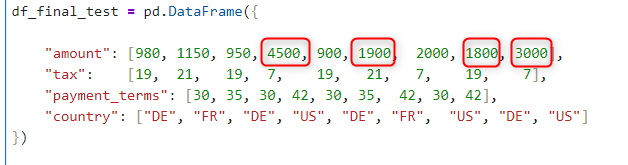



## 5.1 reconstructions = autoencoder.predict(X_final_test)

<class 'numpy.ndarray'>
   amount  tax  payment_terms country
0     980   19             30      DE
1    1150   21             35      FR
2     950   19             30      DE
3    4500    7             42      US
4     900   19             30      DE
5    1900   21             35      FR
6    2000    7             42      US
7    1800   19             30      DE
8    3000    7             42      US
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
<class 'numpy.ndarray'>
mse-test [2.64338119e-03 1.57739173e-03 2.36929468e-03 3.60088973e+00
 5.51800340e-03 5.25945748e-01 2.04989189e-03 5.74185155e-01
 5.84923784e-01]
 reconstructions.shape (9, 6)
<class 'numpy.ndarray'>
X_num_predition:
 [[ 961.02   18.53   29.61]
 [1131.78   20.58   34.88]
 [ 962.12   18.55   29.64]
 [2850.43   -1.3    52.97]
 [ 963.96   18.57   29.7 ]
 [1113.97   19.93   33.93]
 [1988.94    6.41   41.82]
 [ 964.83   18.25   29.36]
 [2333.54    3.33   46.28]]
max. Threshold:  0.0327246010688125
 1.  DE   980 => 961.0 - MSE=0.002

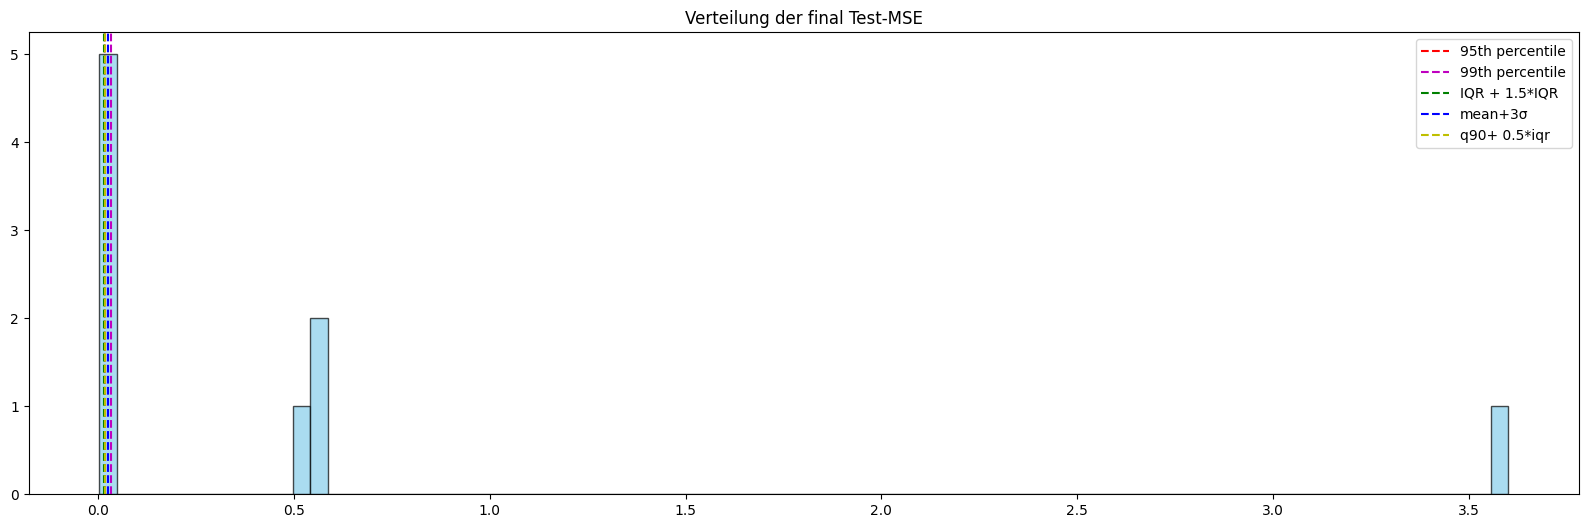

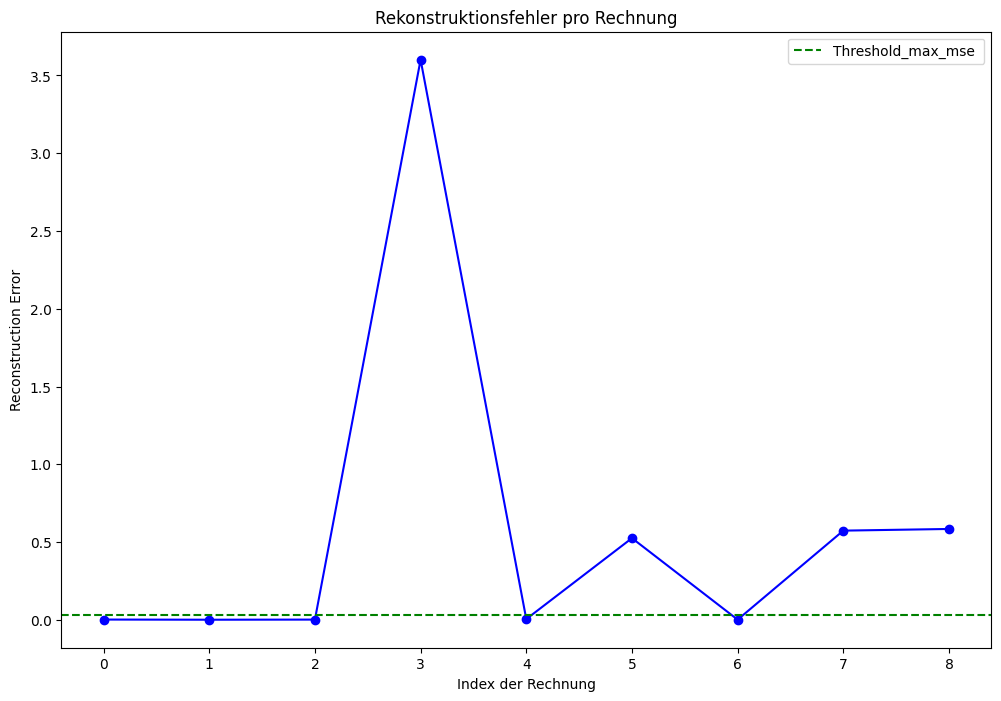

   amount  tax  payment_terms country  reconstruction_mse
3    4500    7             42      US            3.600890
8    3000    7             42      US            0.584924
7    1800   19             30      DE            0.574185
5    1900   21             35      FR            0.525946
4     900   19             30      DE            0.005518
0     980   19             30      DE            0.002643
2     950   19             30      DE            0.002369
6    2000    7             42      US            0.002050
1    1150   21             35      FR            0.001577


In [5]:
df_final_test = pd.DataFrame({

    "amount": [980, 1150, 950, 4500, 900, 1900,  2000, 1800, 3000],
    "tax":    [19,  21,   19,  7,    19,   21,   7,    19,    7],
    "payment_terms": [30, 35, 30, 42, 30, 35,  42, 30, 42],
    "country": ["DE", "FR", "DE", "US", "DE", "FR",  "US", "DE", "US"]
})


#X_test = preprocessor.transform(df_data_test)
X_final_test = preprocessor.transform(df_final_test)
print(type(X_final_test))
print( df_final_test.head(10))

reconstructions = autoencoder.predict(X_final_test)
print(type(reconstructions) )
reconstruction_mse = np.mean(np.power(X_final_test - reconstructions, 2), axis=1)
print("mse-test", reconstruction_mse)
print(" reconstructions.shape", reconstructions.shape)

# Zurückführung von Prediction:
num_scaler = preprocessor.named_transformers_["num"]
X_num_scaled = reconstructions[:, :len(num_features)]
X_num_pred = num_scaler.inverse_transform(X_num_scaled)
print(type(X_num_pred))
np.set_printoptions(suppress=True, precision=2)  # suppress=True = keine Exponentialdarstellung
print("X_num_predition:\n", X_num_pred)


print("max. Threshold: ", threshold_max)

# Ergebnisse
# for i, (country, err) in enumerate(zip(df_X_test["country"], reconstruction_error)):
for i, (country, err) in enumerate(zip(df_final_test["country"], reconstruction_mse)):
    label = "🚨 Anomalie" if err > threshold_max else "✅ Normal"
    print(f"{i+1:2d}. {country:>3}  {df_final_test.iloc[i, 0]:4} => {X_num_pred[i][0]:.1f} - MSE={err:.5f} -> {label}")


plt.figure(figsize=(20, 6))  # <– Breite = 20, Höhe = 6 Zoll
plt.hist(reconstruction_mse, bins=80, alpha=0.7, color='skyblue', edgecolor='black')

plt.axvline(q95, color='r', linestyle='--', label='95th percentile')
plt.axvline(q99, color='m', linestyle='--', label='99th percentile')
plt.axvline(threshold_iqr, color='g', linestyle='--', label='IQR + 1.5*IQR')
plt.axvline(threshold_std, color='b', linestyle='--', label='mean+3σ')
plt.axvline(threshold_90_iqr, color='y', linestyle='--', label='q90+ 0.5*iqr')
plt.legend()
plt.title("Verteilung der final Test-MSE")
plt.show()



#X_pred = autoencoder.predict(X_test)
#reconstruction_error = np.mean(np.square(X_test - X_pred), axis=1)

#  Fehler im DataFrame hinzufügen
df_final_test ["reconstruction_mse"] = reconstruction_mse #  reconstruction_error

#  Schwellenwert setzen (z.B. Mittelwert + 2*Std)
mean_final_test_mse=  reconstruction_mse.mean()
threshold_test_mse = mean_final_test_mse + 2 * reconstruction_mse.std()

#  Plot
plt.figure(figsize=(12,8))
plt.plot(df_final_test.index, df_final_test["reconstruction_mse"], "bo-")
#plt.axhline(mean_final_test_mse, color="red", linestyle="--", label="Final_test_mean_mse")
plt.axhline(threshold_max, color="green", linestyle="--", label="Threshold_max_mse ")
plt.title("Rekonstruktionsfehler pro Rechnung")
plt.xlabel("Index der Rechnung")
plt.ylabel("Reconstruction Error")
plt.legend()
plt.show()

# Sortierte Ansicht
data_sorted = df_final_test.sort_values("reconstruction_mse", ascending=False)
print(data_sorted)



